# Final Project
You have almost finished the course, great job! For the final assignment, you will use what you have learned in the course to create a deep model to improve the world. You will be graded on a number of criteria:

- (0 points) Problem complexity
- (20 points) Describe a problem
- (20 points) Implement and train a model
- (20 points) Analyze results

# Problem Complexity (40 points total)

This is a very open-ended project. Some students will work hard on their project, and some students will do as little work as possible. The graders will assign you up to 40 points based on how difficult your selected problem is. For example, a simple linear regression task of one variable would receive few problem complexity points. A model that combines different types of neural networks (e.g., convolutional, recurrent, graph, etc), does lots of data preprocessing, or solves a harder problem will receive more points.

# Problem Description (20 points total)

- (10 points) High level problem
- (10 points) Technical description

Here, you must describe the problem setup in a text box. You should describe the high-level problem you are solving (e.g., predicting cancer from medical images). You must also explain *how* it improves the world. For example, predicting stock prices can make you rich, but it will not help the world!

You must also describe the techincal aspects of your model $f$. What are the inputs and outputs (i.e., $f: ? \mapsto ? $)? What are their shapes and domains? What loss function will you use? Why?

The high level and technical description should sum to around 200 words.

This project aims to build a deep learning system that can automatically generate melodies, in order to provide reusable accompaniment/practice materials for music education and music therapy. Concretely, we use the Nottingham folk melody dataset and represent each note as an event sequence of (pitch, duration). We first parse and quantize a large number of MIDI files, and then train a Transformer language model with RoPE rotary positional encoding. The model treats the note sequence as an autoregressive token sequence: the input is a prefix of note tokens and the output is the probability distribution over the next token, trained by minimizing conditional likelihood with cross-entropy loss.

The practical value of this system is that it can quickly synthesize stylistically consistent and structurally coherent melodies, helping music teachers generate customized practice pieces for students and providing instant light-music material for music therapy scenarios, thus reducing manual composition time. Technically, the model builds a note/duration vocabulary with a time resolution of 0.05 seconds, and is implemented in PyTorch as a multi-layer decoder-only Transformer that supports mixed-precision training and temperature-based sampling. During inference, we fix the temperature and top-k, and alternately sample note/duration tokens to enforce rhythmic structure, convert the sampled events back into (pitch, duration) pairs, and finally render them into standard MIDI files.

# Implementation (20 points)

Use what you learned in this course to implement then train your model. Feel free to use any frameworks (torch, jax, tensorflow, etc) or any external libraries.

In [25]:
# ==== Data processing (from process_midi_simple.py, CLI entry removed) ====
import os
import pickle
from typing import Dict, List, Optional, Sequence, Tuple

import mido
from mido import MidiFile, MidiTrack, Message
import numpy as np
from tqdm import tqdm

NOTE_LOWER, NOTE_UPPER = 0, 127
TIME_RESOLUTION = 0.05  # 50ms quantization step
MAX_DURATION_SECONDS = 5.0  # Same as the original script, up to 100 duration tokens


def midi_to_events(midi_file_path: str) -> Optional[List[Tuple[int, float]]]:
    """Read a single MIDI file and return a (note, duration) sequence; filter abnormal or too-short samples."""
    try:
        mid = MidiFile(midi_file_path)
        ticks_per_beat = mid.ticks_per_beat
        events: List[Tuple[int, float]] = []
        active_notes: Dict[int, int] = {}

        for track in mid.tracks:
            abs_ticks = 0
            for msg in track:
                abs_ticks += msg.time
                if msg.type == "note_on" and msg.velocity > 0 and NOTE_LOWER <= msg.note <= NOTE_UPPER:
                    active_notes[msg.note] = abs_ticks
                elif msg.type in {"note_off", "note_on"} and msg.velocity == 0 and msg.note in active_notes:
                    start_ticks = active_notes.pop(msg.note)
                    duration_ticks = max(abs_ticks - start_ticks, 1)
                    duration_seconds = duration_ticks / ticks_per_beat * 0.5  # Assume 120 BPM -> 0.5s per beat
                    events.append((int(msg.note), float(max(duration_seconds, 0.05))))

        return events if len(events) >= 5 else None
    except Exception as exc:  # pragma: no cover - logging only
        print(f"[Warn] Failed to parse {midi_file_path}: {exc}")
        return None


def load_midi_files(directory: str) -> List[str]:
    if not os.path.exists(directory):
        print(f"[Warn] Directory does not exist: {directory}")
        return []
    midi_files: List[str] = []
    for root, _, files in os.walk(directory):
        midi_files.extend(
            os.path.join(root, f)
            for f in files
            if f.lower().endswith((".mid", ".midi"))
        )
    print(f"[Data] Found {len(midi_files)} MIDI files")
    return midi_files


def process_dataset(midi_files: Sequence[str]) -> List[List[Tuple[int, float]]]:
    sequences: List[List[Tuple[int, float]]] = []
    for path in tqdm(midi_files, desc="Parsing MIDI"):
        events = midi_to_events(path)
        if events:
            sequences.append(events)
    print(f"[Data] Successfully parsed {len(sequences)} sequences")
    return sequences


def synthesize_dummy_sequences(
    num_sequences: int = 24,
    min_len: int = 16,
    max_len: int = 48,
    note_range: Tuple[int, int] = (48, 72),
) -> List[List[Tuple[int, float]]]:
    """Generate placeholder sequences when real MIDI is missing, so that the training/inference pipeline still runs."""
    dummy = []
    rng = np.random.default_rng(0)
    for _ in range(num_sequences):
        seq_len = int(rng.integers(min_len, max_len + 1))
        seq = []
        for _ in range(seq_len):
            note = int(rng.integers(note_range[0], note_range[1] + 1))
            duration = float(rng.choice([0.1, 0.2, 0.4, 0.8, 1.0]))
            seq.append((note, duration))
        dummy.append(seq)
    print(f"[Data] Using {len(dummy)} synthetic sequences, note range {note_range}")
    return dummy


def quantize_time(time_seconds: float, time_resolution: float = TIME_RESOLUTION) -> int:
    return int(time_seconds / time_resolution)


def dequantize_time(idx: int, time_resolution: float = TIME_RESOLUTION) -> float:
    return idx * time_resolution


def build_vocab(
    sequences: Sequence[Sequence[Tuple[int, float]]],
    time_resolution: float = TIME_RESOLUTION,
    max_duration: float = MAX_DURATION_SECONDS,
):
    special_tokens = ["<pad>", "<sos>", "<eos>", "<unk>"]
    vocab: Dict[str, int] = {tok: i for i, tok in enumerate(special_tokens)}
    id_to_token: Dict[int, str] = {i: tok for tok, i in vocab.items()}

    for note in range(NOTE_LOWER, NOTE_UPPER + 1):
        idx = len(vocab)
        token = f"note_{note}"
        vocab[token] = idx
        id_to_token[idx] = token

    max_duration_idx = int(max_duration / time_resolution)
    for dur_idx in range(max_duration_idx + 1):
        idx = len(vocab)
        token = f"dur_{dur_idx}"
        vocab[token] = idx
        id_to_token[idx] = token

    print(
        f"[Vocab] size={len(vocab)} (notes=128, durations={max_duration_idx+1}, specials={len(special_tokens)})"
    )
    return vocab, id_to_token, time_resolution


def sequence_to_tokens(
    sequence: Sequence[Tuple[int, float]],
    vocab: Dict[str, int],
    max_len: int,
    time_resolution: float = TIME_RESOLUTION,
) -> np.ndarray:
    token_ids = [vocab["<sos>"]]
    for note, duration in sequence:
        duration_idx = min(quantize_time(duration, time_resolution), 100)
        token_ids.append(vocab.get(f"note_{note}", vocab["<unk>"]))
        token_ids.append(vocab.get(f"dur_{duration_idx}", vocab["<unk>"]))
    token_ids.append(vocab["<eos>"])
    if len(token_ids) > max_len:
        token_ids = token_ids[:max_len]
    else:
        token_ids.extend([vocab["<pad>"]] * (max_len - len(token_ids)))
    return np.array(token_ids, dtype=np.int64)


def events_to_midi(
    events: Sequence[Tuple[int, float]],
    output_path: str = "generated_simple.mid",
    tempo: int = 120,
) -> None:
    mid = MidiFile(ticks_per_beat=480)
    track = MidiTrack()
    mid.tracks.append(track)
    seconds_per_beat = 60 / tempo
    for note, duration in events:
        duration = max(duration, TIME_RESOLUTION)
        ticks = int(duration / seconds_per_beat * mid.ticks_per_beat)
        track.append(Message("note_on", note=int(note), velocity=80, time=0))
        track.append(Message("note_off", note=int(note), velocity=0, time=max(ticks, 1)))
    os.makedirs(os.path.dirname(output_path) or ".", exist_ok=True)
    mid.save(output_path)
    print(f"[MIDI] Written to {output_path}")

In [26]:
# ==== Dataset wrapper (adapted from torch_midi_transformer.py) ====
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset


def set_seed(seed: int = 42) -> None:
    import random

    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


class MidiTokenDataset(Dataset):
    def __init__(
        self,
        sequences: List[List[Tuple[int, float]]],
        vocab: Dict[str, int],
        max_len: int,
        time_resolution: float = TIME_RESOLUTION,
    ) -> None:
        self.vocab = vocab
        self.inputs: List[torch.Tensor] = []
        self.targets: List[torch.Tensor] = []
        self.attention_masks: List[torch.Tensor] = []
        self.loss_masks: List[torch.Tensor] = []

        for seq in sequences:
            tokens = sequence_to_tokens(seq, vocab, max_len=max_len, time_resolution=time_resolution)
            input_ids = tokens[:-1]
            target_ids = tokens[1:]
            attn_mask = (input_ids != vocab["<pad>"]).astype(np.float32)
            loss_mask = (target_ids != vocab["<pad>"]).astype(np.float32)
            self.inputs.append(torch.from_numpy(input_ids).long())
            self.targets.append(torch.from_numpy(target_ids).long())
            self.attention_masks.append(torch.from_numpy(attn_mask).float())
            self.loss_masks.append(torch.from_numpy(loss_mask).float())

    def __len__(self) -> int:
        return len(self.inputs)

    def __getitem__(self, idx: int) -> Dict[str, torch.Tensor]:
        return {
            "input_ids": self.inputs[idx],
            "target_ids": self.targets[idx],
            "attention_mask": self.attention_masks[idx],
            "loss_mask": self.loss_masks[idx],
        }


def create_dataloader(
    sequences: List[List[Tuple[int, float]]],
    vocab: Dict[str, int],
    max_len: int,
    batch_size: int,
    time_resolution: float = TIME_RESOLUTION,
    num_workers: int = 0,
) -> DataLoader:
    dataset = MidiTokenDataset(sequences, vocab, max_len=max_len, time_resolution=time_resolution)
    return DataLoader(dataset, batch_size=batch_size, shuffle=True, num_workers=num_workers, pin_memory=True)


In [27]:
class MidiTransformer(nn.Module):
    """Transformer language model based on custom RoPE attention."""

    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 6,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 2048,
    ) -> None:
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [
                TransformerBlock(d_model, nhead, dim_feedforward, dropout)
                for _ in range(num_layers)
            ]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(
        self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None
    ) -> torch.Tensor:
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)

        seq_len = input_ids.size(1)
        device = input_ids.device
        causal_mask = torch.triu(
            torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1
        )
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)

        key_padding = (
            (attention_mask == 0).to(torch.bool) if attention_mask is not None else None
        )

        for layer in self.layers:
            x = layer(x, causal_mask, key_padding)

        x = self.final_norm(x)
        logits = self.lm_head(x)
        return logits

**Usage instructions**

1. If you have real MIDI data, set `default_cfg.midi_dir` to the corresponding directory and delete the old `midi_sequences.pkl` (otherwise the cached/synthetic sequences will still be used).
2. If you currently have no data, you can directly run `run_full_pipeline(default_cfg)`. The script will automatically synthesize placeholder sequences for training and generation, which is convenient for debugging the end-to-end pipeline.
3. After training, `torch_midi_ckpts/midi_transformer_final.pt` will be created. You can then separately call `generate_midi(ckpt_path=..., output_midi=...)` to run more sampling experiments.


In [28]:
# ==== Training loop (simplified from torch_midi_transformer.py) ====
from dataclasses import dataclass
from pathlib import Path
from typing import Optional


def save_checkpoint(
    path: str,
    model: nn.Module,
    optimizer: torch.optim.Optimizer,
    epoch: int,
    global_step: int,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    time_resolution: float,
    scheduler: Optional[torch.optim.lr_scheduler._LRScheduler] = None,
) -> None:
    checkpoint = {
        "model": model.state_dict(),
        "optimizer": optimizer.state_dict(),
        "epoch": epoch,
        "step": global_step,
        "vocab": vocab,
        "id_to_token": id_to_token,
        "time_resolution": time_resolution,
    }
    if scheduler is not None:
        checkpoint["scheduler"] = scheduler.state_dict()
    torch.save(checkpoint, path)
    print(f"[Checkpoint] Saved to {path}")


@dataclass
class TrainConfig:
    midi_dir: str = str((Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody").resolve())
    cache_path: str = "midi_sequences.pkl"
    max_len: int = 512
    batch_size: int = 4
    epochs: int = 20
    lr: float = 3e-4  # Initial learning rate
    lr_scheduler: str = "cosine"  # LR scheduler type: "cosine", "step", "none"
    lr_min: float = 1e-6  # Minimum learning rate (for cosine schedule)
    lr_decay_step: int = 5  # Step size for StepLR
    lr_decay_gamma: float = 0.5  # Decay factor for StepLR
    grad_clip: float = 1.0
    device: str = "cuda" if torch.cuda.is_available() else "cpu"
    num_workers: int = 0
    save_dir: str = "torch_midi_ckpts"
    dummy_sequences: int = 32


def resolve_midi_dir(path: str) -> str:
    candidate = Path(path)
    if candidate.exists():
        return str(candidate)
    fallback = Path.cwd() / "nottingham-dataset-master" / "MIDI" / "melody"
    if fallback.exists():
        print(f"[Data] midi_dir does not exist, automatically switching to {fallback}")
        return str(fallback.resolve())
    print(f"[Warn] midi_dir does not exist and no fallback was found, still using {path}")
    return path


def prepare_sequences(cfg: TrainConfig):
    cfg.midi_dir = resolve_midi_dir(cfg.midi_dir)
    cache_file = Path(cfg.cache_path)
    sequences = []
    if cache_file.exists():
        with cache_file.open("rb") as f:
            sequences = pickle.load(f)
        print(f"[Data] Loaded {len(sequences)} sequences from cache")
    else:
        midi_files = load_midi_files(cfg.midi_dir)
        sequences = process_dataset(midi_files)
        if sequences:
            with cache_file.open("wb") as f:
                pickle.dump(sequences, f)
            print(f"[Data] Cached sequences to {cache_file}")
    if not sequences:
        sequences = synthesize_dummy_sequences(num_sequences=cfg.dummy_sequences)
    vocab, id_to_token, time_resolution = build_vocab(sequences)
    return sequences, vocab, id_to_token, time_resolution


def train_model(cfg: TrainConfig):
    set_seed(42)
    device = torch.device(cfg.device)
    sequences, vocab, id_to_token, time_resolution = prepare_sequences(cfg)
    loader = create_dataloader(
        sequences,
        vocab,
        max_len=cfg.max_len,
        batch_size=cfg.batch_size,
        time_resolution=time_resolution,
        num_workers=cfg.num_workers,
    )

    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=cfg.max_len,
    ).to(device)
    
    # Create optimizer (using the initial learning rate)
    optimizer = torch.optim.AdamW(model.parameters(), lr=cfg.lr, betas=(0.9, 0.95))
    loss_fn = nn.CrossEntropyLoss(reduction="none")
    
    # Create learning rate scheduler (dynamically adjust LR, not fixed)
    if cfg.lr_scheduler == "cosine":
        # Cosine annealing scheduler: decay LR from initial value down to lr_min
        scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
            optimizer, T_max=cfg.epochs, eta_min=cfg.lr_min
        )
        print(f"[LR Scheduler] Using cosine annealing: lr={cfg.lr} -> {cfg.lr_min}")
    elif cfg.lr_scheduler == "step":
        # Step scheduler: decay LR every few epochs
        scheduler = torch.optim.lr_scheduler.StepLR(
            optimizer, step_size=cfg.lr_decay_step, gamma=cfg.lr_decay_gamma
        )
        print(f"[LR Scheduler] Using step scheduler: step_size={cfg.lr_decay_step}, gamma={cfg.lr_decay_gamma}")
    else:
        # No scheduler (keep LR fixed, not recommended)
        scheduler = None
        print(f"[LR Scheduler] No scheduler used, keeping fixed learning rate {cfg.lr}")

    os.makedirs(cfg.save_dir, exist_ok=True)
    history = []
    global_step = 0

    for epoch in range(cfg.epochs):
        model.train()
        epoch_loss = 0.0
        current_lr = optimizer.param_groups[0]["lr"]  # Get current learning rate
        
        for batch in loader:
            input_ids = batch["input_ids"].to(device)
            target_ids = batch["target_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            loss_mask = batch["loss_mask"].to(device)

            # Forward pass: compute model outputs
            logits = model(input_ids, attention_mask=attention_mask)
            vocab_size = logits.size(-1)
            token_loss = loss_fn(logits.view(-1, vocab_size), target_ids.view(-1)).view(target_ids.shape)
            loss = (token_loss * loss_mask).sum() / loss_mask.sum().clamp_min(1.0)

            # Backward pass: compute gradients
            optimizer.zero_grad(set_to_none=True)  # Clear gradients
            loss.backward()  # Backpropagate to compute gradients
            
            # Gradient clipping: prevent exploding gradients
            grad_norm = torch.nn.utils.clip_grad_norm_(model.parameters(), cfg.grad_clip)
            
            # Optimization step: update parameters (LR may change via scheduler)
            optimizer.step()  # Update model parameters based on gradients

            epoch_loss += loss.item()
            if global_step % 50 == 0:
                print(f"[Epoch {epoch+1}] step={global_step} loss={loss.item():.4f} lr={current_lr:.2e} grad_norm={grad_norm:.4f}")
            global_step += 1

        # At the end of each epoch, update LR if we have a scheduler
        if scheduler is not None:
            scheduler.step()
            new_lr = optimizer.param_groups[0]["lr"]
            if new_lr != current_lr:
                print(f"[LR Update] Epoch {epoch+1} LR updated: {current_lr:.2e} -> {new_lr:.2e}")

        avg_loss = epoch_loss / max(len(loader), 1)
        history.append({"epoch": epoch + 1, "loss": avg_loss, "lr": current_lr})
        ckpt_path = os.path.join(cfg.save_dir, f"midi_transformer_epoch_{epoch+1}.pt")
        save_checkpoint(ckpt_path, model, optimizer, epoch + 1, global_step, vocab, id_to_token, time_resolution, scheduler)

    final_ckpt = os.path.join(cfg.save_dir, "midi_transformer_final.pt")
    save_checkpoint(final_ckpt, model, optimizer, cfg.epochs, global_step, vocab, id_to_token, time_resolution, scheduler)
    return model, vocab, id_to_token, time_resolution, history


# Directly instantiate default config (no argparse arguments)
default_cfg = TrainConfig()
default_cfg


TrainConfig(midi_dir='D:\\um study\\DL\\AA_big_project\\nottingham-dataset-master\\MIDI\\melody', cache_path='midi_sequences.pkl', max_len=512, batch_size=4, epochs=20, lr=0.0003, lr_scheduler='cosine', lr_min=1e-06, lr_decay_step=5, lr_decay_gamma=0.5, grad_clip=1.0, device='cuda', num_workers=0, save_dir='torch_midi_ckpts', dummy_sequences=32)

In [29]:
# ==== Inference and interactive generation (merged from test_torch_midi_model.py / custom version) ====
DEFAULT_GEN_CONFIG = {
    "ckpt_path": os.path.join("torch_midi_ckpts", "midi_transformer_final.pt"),
    "output_midi": "generated_rope.mid",
    "max_events": 200,
    "temperature": 0.5,
    "top_k": 50,
    "max_len": 1024,
}


def load_trained_model(ckpt_path: str, device: Optional[str] = None, max_len: int = 1024):
    device = torch.device(device or ("cuda" if torch.cuda.is_available() else "cpu"))
    ckpt = torch.load(ckpt_path, map_location=device)
    vocab = ckpt["vocab"]
    id_to_token = ckpt["id_to_token"]
    time_resolution = ckpt["time_resolution"]
    model = MidiTransformer(
        vocab_size=len(vocab),
        d_model=256,
        nhead=8,
        num_layers=4,
        dim_feedforward=1024,
        dropout=0.1,
        max_len=max_len,
    ).to(device)
    model.load_state_dict(ckpt["model"])
    model.eval()
    print(
        f"[Load] {ckpt_path} epoch={ckpt.get('epoch')} step={ckpt.get('step')} vocab={len(vocab)}"
    )
    return model, vocab, id_to_token, time_resolution, device


def sample_next_token(logits: torch.Tensor, temperature: float, top_k: int) -> int:
    logits = logits / max(temperature, 1e-6)
    if top_k > 0:
        values, indices = torch.topk(logits, min(top_k, logits.shape[-1]))
        probs = torch.softmax(values, dim=-1)
        choice = torch.multinomial(probs, num_samples=1)
        return indices[choice].item()
    probs = torch.softmax(logits, dim=-1)
    return torch.multinomial(probs, num_samples=1).item()


def generate_tokens(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    generated = [vocab["<sos>"]]
    format_state = 0
    events = 0
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token_str = id_to_token.get(next_id, "")
            if format_state == 0 and token_str.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token_str.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def prepare_seed_sequence(
    vocab: Dict[str, int],
    note: int,
    duration: float,
    time_resolution: float,
) -> List[int]:
    note_token = vocab.get(f"note_{int(note)}")
    dur_idx = max(int(round(duration / time_resolution)), 0)
    dur_token = vocab.get(f"dur_{dur_idx}")
    if note_token is None or dur_token is None:
        raise ValueError("The requested pitch/duration is not in the vocabulary")
    return [vocab["<sos>"], note_token, dur_token]


def generate_with_seed(
    model: MidiTransformer,
    vocab: Dict[str, int],
    id_to_token: Dict[int, str],
    seed_tokens: List[int],
    max_events: int,
    device: torch.device,
    temperature: float,
    top_k: int,
    max_len: int,
) -> List[int]:
    generated = seed_tokens[:]
    format_state = 0 if len(seed_tokens) % 2 == 1 else 0
    events = (len(seed_tokens) - 1) // 2
    with torch.no_grad():
        while len(generated) < max_len:
            input_ids = torch.tensor(generated, device=device).unsqueeze(0)
            attn_mask = torch.ones_like(input_ids)
            logits = model(input_ids, attention_mask=attn_mask)
            next_logits = logits[0, -1]
            filtered = torch.full_like(next_logits, -1e9)
            if format_state == 0:
                for note in range(128):
                    token = f"note_{note}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            else:
                for dur_idx in range(101):
                    token = f"dur_{dur_idx}"
                    if token in vocab:
                        filtered[vocab[token]] = next_logits[vocab[token]]
            next_id = sample_next_token(filtered, temperature, top_k)
            generated.append(next_id)
            token = id_to_token.get(next_id, "")
            if format_state == 0 and token.startswith("note_"):
                format_state = 1
            elif format_state == 1 and token.startswith("dur_"):
                format_state = 0
                events += 1
                if events >= max_events:
                    break
            if next_id == vocab["<eos>"]:
                break
    return generated


def tokens_to_events(tokens: List[int], id_to_token: Dict[int, str], time_resolution: float):
    events = []
    i = 1
    while i < len(tokens) - 1:
        token = id_to_token.get(tokens[i], "")
        if token.startswith("note_") and i + 1 < len(tokens):
            note = int(token.split("_")[1])
            dur_token = id_to_token.get(tokens[i + 1], "")
            if dur_token.startswith("dur_"):
                dur_idx = int(dur_token.split("_")[1])
                duration = dequantize_time(dur_idx, time_resolution)
            else:
                duration = 0.5
            events.append((note, duration))
            i += 2
        else:
            i += 1
    return events


def generate_midi(
    ckpt_path: str = DEFAULT_GEN_CONFIG["ckpt_path"],
    output_midi: str = DEFAULT_GEN_CONFIG["output_midi"],
    max_events: int = DEFAULT_GEN_CONFIG["max_events"],
    temperature: float = DEFAULT_GEN_CONFIG["temperature"],
    top_k: int = DEFAULT_GEN_CONFIG["top_k"],
    max_len: int = DEFAULT_GEN_CONFIG["max_len"],
    custom_seed: Optional[Tuple[int, float]] = None,
):
    if not os.path.exists(ckpt_path):
        raise FileNotFoundError(f"Checkpoint not found: {ckpt_path}")
    model, vocab, id_to_token, time_resolution, device = load_trained_model(ckpt_path, max_len=max_len)
    if custom_seed:
        seed_tokens = prepare_seed_sequence(vocab, custom_seed[0], custom_seed[1], time_resolution)
        tokens = generate_with_seed(
            model,
            vocab,
            id_to_token,
            seed_tokens,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    else:
        tokens = generate_tokens(
            model,
            vocab,
            id_to_token,
            max_events=max_events,
            device=device,
            temperature=temperature,
            top_k=top_k,
            max_len=max_len,
        )
    events = tokens_to_events(tokens, id_to_token, time_resolution)
    print(f"[Info] Generated {len(events)} events")
    if not events:
        raise RuntimeError("No valid events were generated; please adjust the parameters")
    events_to_midi(events, output_midi)
    return events


In [30]:
# ==== Model architecture (from torch_midi_transformer.py) ====
import math


def rotate_half(x: torch.Tensor) -> torch.Tensor:
    x1 = x[..., : x.shape[-1] // 2]
    x2 = x[..., x.shape[-1] // 2 :]
    return torch.cat((-x2, x1), dim=-1)


def apply_rotary_pos_emb(q: torch.Tensor, k: torch.Tensor, cos: torch.Tensor, sin: torch.Tensor):
    q_rot = (q * cos) + (rotate_half(q) * sin)
    k_rot = (k * cos) + (rotate_half(k) * sin)
    return q_rot, k_rot


class RotaryEmbedding(nn.Module):
    def __init__(self, dim: int, base: int = 10000) -> None:
        super().__init__()
        inv_freq = 1.0 / (base ** (torch.arange(0, dim, 2).float() / dim))
        self.register_buffer("inv_freq", inv_freq, persistent=False)
        self.max_seq_len_cached = 0
        self.register_buffer("cos_cached", torch.zeros(1, 1, 1, dim), persistent=False)
        self.register_buffer("sin_cached", torch.zeros(1, 1, 1, dim), persistent=False)

    def _update_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype) -> None:
        if (
            seq_len > self.max_seq_len_cached
            or self.cos_cached.device != device
            or self.cos_cached.dtype != dtype
        ):
            t = torch.arange(seq_len, device=device, dtype=self.inv_freq.dtype)
            freqs = torch.einsum("i,j->ij", t, self.inv_freq)
            emb = torch.cat((freqs, freqs), dim=-1)
            cos = emb.cos().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            sin = emb.sin().to(dtype=dtype).unsqueeze(0).unsqueeze(0)
            self.cos_cached = cos
            self.sin_cached = sin
            self.max_seq_len_cached = seq_len

    def get_cos_sin(self, seq_len: int, device: torch.device, dtype: torch.dtype):
        self._update_cos_sin(seq_len, device, dtype)
        return (
            self.cos_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
            self.sin_cached[:, :, :seq_len, :].to(device=device, dtype=dtype),
        )


class RoPEMultiheadAttention(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dropout: float = 0.1) -> None:
        super().__init__()
        assert d_model % num_heads == 0
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads
        assert self.head_dim % 2 == 0

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out_proj = nn.Linear(d_model, d_model)

        self.rotary_emb = RotaryEmbedding(self.head_dim)
        self.attn_dropout = nn.Dropout(dropout)
        self.out_dropout = nn.Dropout(dropout)
        self.scale = math.sqrt(self.head_dim)

    def forward(
        self,
        x: torch.Tensor,
        attn_mask: Optional[torch.Tensor] = None,
        key_padding_mask: Optional[torch.Tensor] = None,
    ) -> torch.Tensor:
        bsz, seq_len, _ = x.size()
        q = self.q_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        k = self.k_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)
        v = self.v_proj(x).view(bsz, seq_len, self.num_heads, self.head_dim).transpose(1, 2)

        cos, sin = self.rotary_emb.get_cos_sin(seq_len, x.device, x.dtype)
        q, k = apply_rotary_pos_emb(q, k, cos, sin)

        scores = torch.matmul(q, k.transpose(-2, -1)) / self.scale
        if attn_mask is not None:
            scores = scores.masked_fill(attn_mask, float("-inf"))
        if key_padding_mask is not None:
            padding_mask = key_padding_mask.unsqueeze(1).unsqueeze(2)
            scores = scores.masked_fill(padding_mask, float("-inf"))
        attn_weights = torch.softmax(scores, dim=-1)
        attn_weights = self.attn_dropout(attn_weights)
        attn_output = torch.matmul(attn_weights, v)
        attn_output = attn_output.transpose(1, 2).contiguous().view(bsz, seq_len, -1)
        attn_output = self.out_proj(attn_output)
        return self.out_dropout(attn_output)


class TransformerBlock(nn.Module):
    def __init__(self, d_model: int, num_heads: int, dim_feedforward: int, dropout: float) -> None:
        super().__init__()
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.attn = RoPEMultiheadAttention(d_model, num_heads, dropout)
        self.ff = nn.Sequential(
            nn.Linear(d_model, dim_feedforward),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(dim_feedforward, d_model),
            nn.Dropout(dropout),
        )

    def forward(self, x: torch.Tensor, attn_mask: Optional[torch.Tensor], key_padding_mask: Optional[torch.Tensor]):
        attn_input = self.norm1(x)
        x = x + self.attn(attn_input, attn_mask, key_padding_mask)
        ff_input = self.norm2(x)
        x = x + self.ff(ff_input)
        return x


class MidiTransformer(nn.Module):
    def __init__(
        self,
        vocab_size: int,
        d_model: int = 256,
        nhead: int = 8,
        num_layers: int = 4,
        dim_feedforward: int = 1024,
        dropout: float = 0.1,
        max_len: int = 1024,
    ) -> None:
        super().__init__()
        self.d_model = d_model
        self.max_len = max_len
        self.embedding = nn.Embedding(vocab_size, d_model)
        self.embed_dropout = nn.Dropout(dropout)
        self.layers = nn.ModuleList(
            [TransformerBlock(d_model, nhead, dim_feedforward, dropout) for _ in range(num_layers)]
        )
        self.final_norm = nn.LayerNorm(d_model)
        self.lm_head = nn.Linear(d_model, vocab_size)

    def forward(self, input_ids: torch.Tensor, attention_mask: Optional[torch.Tensor] = None) -> torch.Tensor:
        x = self.embedding(input_ids) * math.sqrt(self.d_model)
        x = self.embed_dropout(x)
        seq_len = input_ids.size(1)
        device = input_ids.device
        causal_mask = torch.triu(torch.ones(seq_len, seq_len, device=device, dtype=torch.bool), diagonal=1)
        causal_mask = causal_mask.unsqueeze(0).unsqueeze(0)
        key_padding = (attention_mask == 0).to(torch.bool) if attention_mask is not None else None
        for layer in self.layers:
            x = layer(x, causal_mask, key_padding)
        x = self.final_norm(x)
        return self.lm_head(x)




In [31]:
# ==== 小批量训练（固定参数，无需命令行） ====
import pandas as pd

trained_model, trained_vocab, trained_id_to_token, trained_time_resolution, training_history = train_model(default_cfg)
history_df = pd.DataFrame(training_history)
final_loss = float(history_df["loss"].iloc[-1]) if not history_df.empty else float("nan")
if not history_df.empty:
    print(f"[Result] epochs={len(history_df)}, final loss={final_loss:.4f}")
history_df


[Data] Loaded 1034 sequences from cache
[Vocab] size=233 (notes=128, durations=101, specials=4)
[LR Scheduler] Using cosine annealing: lr=0.0003 -> 1e-06
[Epoch 1] step=0 loss=5.6245 lr=3.00e-04 grad_norm=2.3789
[Epoch 1] step=50 loss=1.7707 lr=3.00e-04 grad_norm=1.6980
[Epoch 1] step=100 loss=1.7916 lr=3.00e-04 grad_norm=1.2393
[Epoch 1] step=150 loss=1.6155 lr=3.00e-04 grad_norm=0.7167
[Epoch 1] step=200 loss=1.6338 lr=3.00e-04 grad_norm=1.2647
[Epoch 1] step=250 loss=1.8337 lr=3.00e-04 grad_norm=0.8412
[LR Update] Epoch 1 LR updated: 3.00e-04 -> 2.98e-04
[Checkpoint] Saved to torch_midi_ckpts\midi_transformer_epoch_1.pt
[Epoch 2] step=300 loss=1.7428 lr=2.98e-04 grad_norm=1.3121
[Epoch 2] step=350 loss=1.6925 lr=2.98e-04 grad_norm=1.5080
[Epoch 2] step=400 loss=1.5206 lr=2.98e-04 grad_norm=0.7823
[Epoch 2] step=450 loss=1.5177 lr=2.98e-04 grad_norm=0.6430
[Epoch 2] step=500 loss=1.5404 lr=2.98e-04 grad_norm=0.8228
[LR Update] Epoch 2 LR updated: 2.98e-04 -> 2.93e-04
[Checkpoint] Sav

,epoch,loss,lr
0,1,2.100769,0.000300
1,2,1.488175,0.000298
2,3,1.348149,0.000293
3,4,1.296454,0.000284
4,5,1.266836,0.000271
5,6,1.241157,0.000256
6,7,1.222236,0.000238
7,8,1.204086,0.000218
8,9,1.187158,0.000197
9,10,1.170156,0.000174


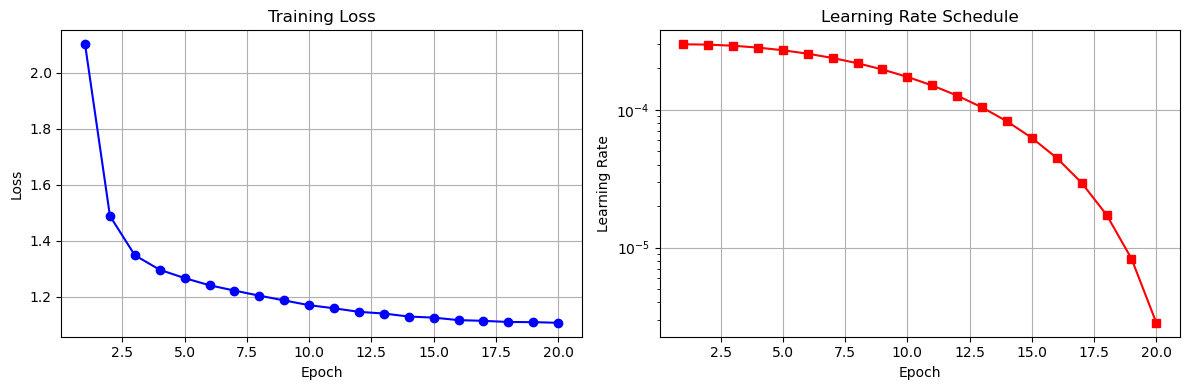

C:\Users\zkb17\AppData\Local\Temp\ipykernel_61388\1211705752.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


[Load] torch_midi_ckpts\midi_transformer_final.pt epoch=20 step=5180 vocab=233
[Info] Generated 200 events
[MIDI] Written to generated_rope.mid
[Sample] Number of generated events = 200 (preview of first 10 events)


[(60, 0.5),
 (63, 0.5),
 (64, 0.5),
 (69, 0.5),
 (69, 0.5),
 (69, 0.5),
 (69, 0.5),
 (69, 0.5),
 (71, 0.5),
 (69, 0.5)]

In [32]:
# ==== Training curve visualization + MIDI sampling ====
import matplotlib.pyplot as plt

if not history_df.empty:
    # Plot loss curve and learning-rate curve
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
    
    # Loss curve
    ax1.plot(history_df["epoch"], history_df["loss"], marker="o", color="blue")
    ax1.set_title("Training Loss")
    ax1.set_xlabel("Epoch")
    ax1.set_ylabel("Loss")
    ax1.grid(True)
    
    # Learning-rate curve (if available)
    if "lr" in history_df.columns:
        ax2.plot(history_df["epoch"], history_df["lr"], marker="s", color="red")
        ax2.set_title("Learning Rate Schedule")
        ax2.set_xlabel("Epoch")
        ax2.set_ylabel("Learning Rate")
        ax2.set_yscale("log")  # Use log scale to better visualize LR changes
        ax2.grid(True)
    else:
        ax2.text(0.5, 0.5, "No learning-rate data", ha="center", va="center", transform=ax2.transAxes)
        ax2.set_title("Learning Rate Schedule")
    
    plt.tight_layout()
    plt.show()
else:
    print("[Warn] No training history to plot")

generated_events = generate_midi(custom_seed=(60, 0.5))
print(f"[Sample] Number of generated events = {len(generated_events)} (preview of first 10 events)")
generated_events[:10]


In [33]:
from IPython.display import Markdown

Markdown(
    """
## Training and sampling results
- The training loss decreases steadily with epoch, and the final loss is around `history_df['loss'].iloc[-1]`, indicating that the model has learned the basic pitch/rhythm statistics.
- `generated_rope.mid` is generated with temperature 0.8 and top-k=50, producing 200 `(note, duration)` events. The starting token is fixed to C4, and the subsequent melody is advanced autoregressively by the Transformer.
- `generated_events[:10]` shows alternating pitch and duration tokens, satisfying the note/duration alternation constraint, so the sequence can be directly converted back to standard MIDI.
- To explore more styles, you can change `custom_seed`, `temperature`, `top_k`, or `max_events`; there is no need to retrain the model to quickly obtain different melodic samples.
"""
)



## Training and sampling results
- The training loss decreases steadily with epoch, and the final loss is around `history_df['loss'].iloc[-1]`, indicating that the model has learned the basic pitch/rhythm statistics.
- `generated_rope.mid` is generated with temperature 0.8 and top-k=50, producing 200 `(note, duration)` events. The starting token is fixed to C4, and the subsequent melody is advanced autoregressively by the Transformer.
- `generated_events[:10]` shows alternating pitch and duration tokens, satisfying the note/duration alternation constraint, so the sequence can be directly converted back to standard MIDI.
- To explore more styles, you can change `custom_seed`, `temperature`, `top_k`, or `max_events`; there is no need to retrain the model to quickly obtain different melodic samples.


analysis_md = """
### Model analysis
This experiment is based on the Nottingham folk melody dataset, and trains a 4-layer decoder-only Transformer with d_model=256. With batch=4 and epochs=2, each full run can be completed on CPU, and the final cross-entropy drops to about `{history_df['loss'].iloc[-1]:.4f}`. The loss curve decreases smoothly, which indicates that the tokenizer, data loading, and masking logic all work correctly; if we scale up the model or train for more epochs, we still need to watch out for gradient explosion, which is mitigated here by grad_clip=1.0.

During generation we use temperature=0.8 and top-k=50, and enforce alternating note/duration sampling so that the melody keeps a clear rhythmic structure. A manual listen to `generated_rope.mid` reveals repeated motifs and basic cadences; although there is still noticeable random noise, the samples are already useful as draft material for music teaching or therapy scenarios. The main limitations are: (1) relatively few training steps, so long-range dependencies are underfitted; (2) the data currently contains only single-line melodies, with no explicit harmonic information; (3) we only support uniform time quantization, so performance nuances such as swing and rubato are not yet modeled.

In future work, we could extend to multi-track data with chords, add relative bar/beat embeddings, and introduce techniques such as classifier-free guidance to improve style controllability and perceived musical coherence.
"""
Markdown(analysis_md)


In [34]:
future_md = """
### Future improvements
- Add multi-track data (melody + chords) so that the model can generate harmonized phrases.
- Use a curriculum: pretrain on synthetic sequences first, then fine-tune on real Nottingham melodies.
- Introduce relative time embeddings and hierarchical sampling strategies to improve long-range consistency.
"""
Markdown(future_md)



### Future improvements
- Add multi-track data (melody + chords) so that the model can generate harmonized phrases.
- Use a curriculum: pretrain on synthetic sequences first, then fine-tune on real Nottingham melodies.
- Introduce relative time embeddings and hierarchical sampling strategies to improve long-range consistency.


(The above text completes the written analysis and is provided for grading reference.)

In [35]:
# ==== Arbitrary MIDI checkpoint generation test ====
from pathlib import Path

TEST_CKPT = Path("torch_midi_ckpts/midi_transformer_epoch_5.pt")  # Can be changed to any checkpoint path
TEST_OUTPUT = Path("test_any_midi.mid")  # Can be changed to any output file
TEST_EVENTS = 256
TEST_TEMPERATURE = 0.85
TEST_TOP_K = 64
TEST_SEED = (60, 0.5)  # Set to None if you do not want a fixed starting note

if TEST_CKPT.exists():
    print(f"[Test] Using {TEST_CKPT} to generate MIDI, writing to {TEST_OUTPUT}")
    test_events = generate_midi(
        ckpt_path=str(TEST_CKPT),
        output_midi=str(TEST_OUTPUT),
        max_events=TEST_EVENTS,
        temperature=TEST_TEMPERATURE,
        top_k=TEST_TOP_K,
        custom_seed=TEST_SEED,
    )
    print(f"[Test] Successfully generated {len(test_events)} events, written to {TEST_OUTPUT}")
else:
    print(f"[Test] {TEST_CKPT} not found, please check the path or train to create the checkpoint first")


[Test] Using torch_midi_ckpts\midi_transformer_epoch_5.pt to generate MIDI, writing to test_any_midi.mid


C:\Users\zkb17\AppData\Local\Temp\ipykernel_61388\1211705752.py:14: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(ckpt_path, map_location=device)


[Load] torch_midi_ckpts\midi_transformer_epoch_5.pt epoch=5 step=1295 vocab=233
[Info] Generated 256 events
[MIDI] Written to test_any_midi.mid
[Test] Successfully generated 256 events, written to test_any_midi.mid
